<a href="https://colab.research.google.com/github/manbarrvil/Typhoon_USE/blob/main/pss_design.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelado y simulación de máquinas síncronas

In [ ]:
%pip install --upgrade pydae --quiet
%pip install --upgrade pydae-bps --quiet
%pip install --upgrade casadi --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.8/101.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.1/510.1 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 MB 11.1 MB/s eta 0:00:00


In [ ]:
!wget https://raw.githubusercontent.com/pydae/data/refs/heads/main/atydse_data/k13p2.hjson --quiet

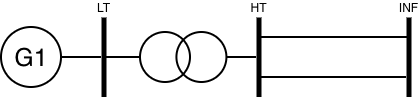

In [ ]:
import plotly.graph_objs as go
import numpy as np
from IPython.core.display import HTML,SVG
from plotly.subplots import make_subplots
from pydae.bps import BpsBuilder
from pydae.core import Builder, Model
import pydae
from pydae import ssa
from pydae.bps.lines import change_line
from pydae.ssa import residue, get_mode, eig
from pydae.bps import BpsBuilder
from pydae.core.builder.casadi_builder import CasadiBuilder
from pydae.core.model.casadi_model import CasadiModel
from pydae.bps.utils.reporter import report_buses, report_gens, report_lines, report_all
from pydae.bps.utils.validator import validate_all, validate_buses, validate_gens
from pydae.utils import read_data

print(pydae.core.__version__)
print(pydae.bps.__version__)

1.5.0
1.7.0


## Construcción del modelo

In [ ]:
grid = BpsBuilder('k13p2.hjson', use_casadi=True)
grid.construct('k13p2')
bld = CasadiBuilder(grid.sys_dict).build()

Building model: k13p2...
Build complete!


## Uso del modelo

### Estado estacionario y análisis de pequeña señal

In [ ]:
model = CasadiModel(bld)
model.ini({},'xy_0.json')
model.report_x()
model.report_y()


States (x):
  delta_LT: 1.193469e+00
  omega_LT: 1.000000e+00
  e1q_LT: 8.998583e-01
  e1d_LT: 4.366215e-01
  x_ab_LT: 2.094489e-02
  x_e_LT: 1.047244e+00
  x_1_gov_LT: 8.019941e-01
  x_2_gov_LT: 8.019941e-01
  x_wo_pss_LT: -3.385006e-29
  x_12_pss_LT: 0.000000e+00
  x_34_pss_LT: 0.000000e+00
  x_lc_LT: 8.019941e-01
  delta_INF: 1.269214e-24
  Domega_INF: 1.990012e-34
  Dv_INF: -2.888126e-23
  v_ref_filtered_INF: 1.000000e+00

Algebraic (y_run):
  V_LT: 1.000000e+00
  theta_LT: 3.880281e-01
  V_HT: 9.837680e-01
  theta_HT: 2.657436e-01
  V_INF: 1.000351e+00
  theta_INF: -1.775379e-03
  i_d_LT: 6.858081e-01
  i_q_LT: 4.408803e-01
  p_g_LT: 8.000000e-01
  q_g_LT: 1.571885e-01
  v_f_LT: 2.047244e+00
  p_m_LT: 8.019941e-01
  v_pss_LT: 0.000000e+00
  p_c_LT: 8.019941e-01
  omega_INF: 1.000000e+00
  omega_coi: 1.000000e+00


In [ ]:
model.A_eval()
ssa.damp_report(model).sort_values('Damp')

 Mode      Real      Imag      Freq.     Damp     
       1   -1.0000     0.0000j    0.0000    1.0000['x_ab_LT']
       2   -2.0000     0.0000j    0.0000    1.0000['x_34_pss_LT']
       3  -20.0000     0.0000j    0.0000    1.0000['x_12_pss_LT']
       4   -0.1000     0.0000j    0.0000    1.0000['x_wo_pss_LT']
       5   -0.0535     7.5868j    1.2075    0.0071['delta_LT' 'omega_LT']
       6   -0.0535    -7.5868j    1.2075    0.0071['delta_LT' 'omega_LT']
       7   -3.1182     3.3737j    0.5369    0.6788['e1q_LT' 'x_e_LT']
       8   -3.1182    -3.3737j    0.5369    0.6788['e1q_LT' 'x_e_LT']
       9   -1.9828     0.0000j    0.0000    1.0000['x_1_gov_LT']
      10   -1.5540     0.0000j    0.0000    1.0000['e1d_LT']
      11   -0.1340     0.0000j    0.0000    1.0000['x_2_gov_LT']
      12   -0.0106     0.0000j    0.0000    1.0000['x_lc_LT']
      13   -0.0100     0.0000j    0.0000    1.0000['delta_INF']
      14   -0.0100     0.0000j    0.0000    1.0000['Domega_INF']
      15   -0.0000 

,Real,Imag,Freq.,Damp,Participation
Mode 6,-0.053495,-7.586817,1.207479,0.007051,"[delta_LT, omega_LT]"
Mode 5,-0.053495,7.586817,1.207479,0.007051,"[delta_LT, omega_LT]"
Mode 8,-3.118232,-3.373676,0.536937,0.678758,"[e1q_LT, x_e_LT]"
Mode 7,-3.118232,3.373676,0.536937,0.678758,"[e1q_LT, x_e_LT]"
Mode 4,-0.100000,0.000000,0.000000,1.000000,[x_wo_pss_LT]
Mode 3,-20.000000,0.000000,0.000000,1.000000,[x_12_pss_LT]
Mode 2,-2.000000,0.000000,0.000000,1.000000,[x_34_pss_LT]
Mode 1,-1.000000,0.000000,0.000000,1.000000,[x_ab_LT]
Mode 9,-1.982807,0.000000,0.000000,1.000000,[x_1_gov_LT]
Mode 10,-1.554011,0.000000,0.000000,1.000000,[e1d_LT]


## Diseño de PSS con constantes K

In [ ]:
import numpy as np

# Parámetros base de la red

SCR = 3.05
X_th = 1/SCR + 0.15
#X_th = 0.2
gen_name = 'LT'
bus_name = 'LT'
V_inf = 1

# 1. Fetch Machine Parameters
X_d  = model.get_value(f'X_d_{gen_name}')
X1d  = model.get_value(f'X1d_{gen_name}')
X_q  = model.get_value(f'X_q_{gen_name}') # Necesario para K1, K4, K5
T1d0 = model.get_value(f'T1d0_{gen_name}')

# 2. Fetch Steady-State Operating Point
delta_0    = model.get_value(f'delta_{gen_name}')
Eq_prime_0 = model.get_value(f'e1q_{gen_name}') # Tensión transitoria eje d (E'q)

# Terminal voltage and angle
V_0     = model.get_value(f'V_{bus_name}')
theta_0 = model.get_value(f'theta_{bus_name}')

# 3. Compute auxiliary steady-state variables
# Tensiones en el eje d-q
v_d0 = V_0 * np.sin(delta_0 - theta_0)
v_q0 = V_0 * np.cos(delta_0 - theta_0)

# Corrientes en el eje d-q considerando el bus infinito y X_th
i_d0 = (Eq_prime_0 - V_inf * np.cos(delta_0)) / (X1d + X_th)
i_q0 = (V_inf * np.sin(delta_0)) / (X_q + X_th)

# 4. Compute the K constants (Heffron-Phillips)
# K1: Coeficiente de par sincronizante
K_1 = (Eq_prime_0 * V_inf * np.cos(delta_0)) / (X1d + X_th) + \
      ((X1d - X_q) * (V_inf**2) * np.cos(2 * delta_0)) / ((X1d + X_th) * (X_q + X_th))

# K2: Sensibilidad de la potencia activa respecto al flujo
K_2 = (V_inf * np.sin(delta_0)) / (X1d + X_th)

# K3: Factor de impedancia
K_3 = (X1d + X_th) / (X_d + X_th)

# K4: Efecto desmagnetizador
K_4 = (V_inf * (X_d - X1d) * np.sin(delta_0)) / (X1d + X_th)

# K5: Sensibilidad de la tensión terminal al ángulo del rotor
K_5 = (v_d0 / V_0) * X_q * (V_inf * np.cos(delta_0) / (X_q + X_th)) - \
      (v_q0 / V_0) * X1d * (V_inf * np.sin(delta_0) / (X1d + X_th))

# K6: Sensibilidad de la tensión terminal al flujo de campo (E'q)
K_6 = (v_q0 / V_0) * (X_th / (X1d + X_th))

# 5. Funciones de transferencia en s=0 (DC Gain)
s = 0
G_vf_Vt = K_3 * K_6 / (1 + s * K_3 * T1d0)
G_P = K_2 * K_3 / (1 + s * K_3 * T1d0)

# Imprimir resultados
Tau = K_3 * T1d0
print("-" * 40)
print("CONSTANTES DE HEFFRON-PHILLIPS")
print("-" * 40)
print(f"K_1 = {K_1:.4f}")
print(f"K_2 = {K_2:.4f}")
print(f"K_3 = {K_3:.4f}")
print(f"K_4 = {K_4:.4f}")
print(f"K_5 = {K_5:.4f}")
print(f"K_6 = {K_6:.4f}")
print("-" * 40)
print("DINÁMICA EN LAZO ABIERTO")
print(f"G_V: Tau = {Tau:.2f} s, Ganancia = {K_3*K_6:.4f}")
print(f"G_P: Ganancia DC = {K_2*K_3:.4f}")

----------------------------------------
CONSTANTES DE HEFFRON-PHILLIPS
----------------------------------------
K_1 = 1.0372
K_2 = 1.1951
K_3 = 0.3400
K_4 = 1.8046
K_5 = -0.0394
K_6 = 0.4256
----------------------------------------
DINÁMICA EN LAZO ABIERTO
G_V: Tau = 2.72 s, Ganancia = 0.1447
G_P: Ganancia DC = 0.4063


In [ ]:
omega_n = 7.586817 # rad/s
s = 1j*omega_n
K_avr = 50
T_avr = 0.2

G_vf_V = K_3 * K_6 / (1 + s * K_3 * T1d0)
G_vf_pe = K_2 * K_3 /(K_3 * T1d0*s + 1)

G_V_pe = K_2/K_6

G_avr = K_avr/(T_avr*s + 1)

T_vref_V = G_vf_V*G_avr/(1 + G_vf_V*G_avr)*G_V_pe

print(f'phase v_ref -> V_t = {np.angle(T_vref_V, deg=True):0.1f}º')

phase v_ref -> V_t = -136.2º


In [ ]:
N_comps = 2
theta_c = -np.angle(T_vref_V)
theta_c_i = theta_c/N_comps
phase_rad_comp = theta_c_i

alpha = (1 + np.sin(phase_rad_comp))/(1 - np.sin(phase_rad_comp))
T_2 = 1/(omega_n*np.sqrt(alpha))
T_1 = alpha*T_2

print(f'G_c = (T_1s + 1)/(T_2s + 1) = ({T_1:0.2f}s + 1)/({T_2:0.2f}s + 1)')

s = 1j*omega_n
G_c = (T_1*s + 1)/(T_2*s + 1)

print(f'G_c = {np.abs(G_c):0.2f} | {np.angle(G_c, deg=True):0.2f}º')

G_c = (T_1s + 1)/(T_2s + 1) = (0.68s + 1)/(0.03s + 1)
G_c = 5.17 | 68.08º


In [ ]:
T_3 = T_1
T_4 = T_2
T_w = 10.0
K_stab = 0.3*0

model = CasadiModel(bld)

params = {'K_stab_pss_LT':K_stab,
           'T_w_pss_LT':T_w,
'T_1_pss_LT':  T_1,
'T_2_pss_LT':  T_2,
'T_3_pss_LT':  T_3,
'T_4_pss_LT':  T_4}

model.ini(params,'xy_0.json')
model.A_eval()
ssa.damp_report(model)

 Mode      Real      Imag      Freq.     Damp     
       1   -1.0000     0.0000j    0.0000    1.0000['x_ab_LT']
       2  -39.1859     0.0000j    0.0000    1.0000['x_34_pss_LT']
       3  -39.1859     0.0000j    0.0000    1.0000['x_12_pss_LT']
       4   -0.1000     0.0000j    0.0000    1.0000['x_wo_pss_LT']
       5   -0.0535     7.5868j    1.2075    0.0071['delta_LT' 'omega_LT']
       6   -0.0535    -7.5868j    1.2075    0.0071['delta_LT' 'omega_LT']
       7   -3.1182     3.3737j    0.5369    0.6788['e1q_LT' 'x_e_LT']
       8   -3.1182    -3.3737j    0.5369    0.6788['e1q_LT' 'x_e_LT']
       9   -1.9828     0.0000j    0.0000    1.0000['x_1_gov_LT']
      10   -1.5540     0.0000j    0.0000    1.0000['e1d_LT']
      11   -0.1340     0.0000j    0.0000    1.0000['x_2_gov_LT']
      12   -0.0106     0.0000j    0.0000    1.0000['x_lc_LT']
      13   -0.0100     0.0000j    0.0000    1.0000['delta_INF']
      14   -0.0100     0.0000j    0.0000    1.0000['Domega_INF']
      15   -0.0000 

,Real,Imag,Freq.,Damp,Participation
Mode 1,-1.000000,0.000000,0.000000,1.000000,[x_ab_LT]
Mode 2,-39.185919,0.000000,0.000000,1.000000,[x_34_pss_LT]
Mode 3,-39.185919,0.000000,0.000000,1.000000,[x_12_pss_LT]
Mode 4,-0.100000,0.000000,0.000000,1.000000,[x_wo_pss_LT]
Mode 5,-0.053495,7.586817,1.207479,0.007051,"[delta_LT, omega_LT]"
Mode 6,-0.053495,-7.586817,1.207479,0.007051,"[delta_LT, omega_LT]"
Mode 7,-3.118232,3.373676,0.536937,0.678758,"[e1q_LT, x_e_LT]"
Mode 8,-3.118232,-3.373676,0.536937,0.678758,"[e1q_LT, x_e_LT]"
Mode 9,-1.982807,0.000000,0.000000,1.000000,[x_1_gov_LT]
Mode 10,-1.554011,0.000000,0.000000,1.000000,[e1d_LT]


In [ ]:
model.A

In [ ]:
model.report_params()

In [ ]:
model.ini(params,'xy_0.json')

# solución en el dominio del tiempo
model.run(1.0,{})
model.run(15.0,{'v_ref_LT': 1.1});
model.post();

In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=model.Time, y=model.get_values('V_LT'), mode='lines', name='V_LT'))

fig.update_layout(
    title='Voltage',
    xaxis_title='Time (s)',
    yaxis_title='Voltage',
    hovermode='closest'
)

fig.show()

In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=model.Time, y=model.get_values('omega_LT'), mode='lines', name='V_LT'))

fig.update_layout(
    title='Voltage',
    xaxis_title='Time (s)',
    yaxis_title='Voltage',
    hovermode='closest'
)

fig.show()

## Método de los residuos

In [ ]:
params.update({'K_stab_pss_LT':0.0, 'K_a_LT':50})
model.ini(params,'xy_0.json')


In [ ]:
eig(model)
mode_idx, lambda_i = get_mode(model, f_min = 1, f_max = 1.5)

omega_n = lambda_i.imag
residue_i = residue(model, 'v_ref_LT', 'V_LT', mode_idx=mode_idx)[0][0]
np.angle(residue_i, deg=True)

In [ ]:
180-36.5

In [ ]:

N_comps = 2


print(np.angle(residue_i,deg=True))
phase_rad_comp = np.angle(residue_i)
phase_rad_per_leadlag = phase_rad_comp/N_comps
print(f'phase per lead-lag = {np.rad2deg(phase_rad_per_leadlag):0.2f}')
alpha = (1 + np.sin(phase_rad_per_leadlag))/(1 - np.sin(phase_rad_per_leadlag))
T_2 = 1/(omega_n*np.sqrt(alpha))
T_1 = alpha*T_2

print(f'G_c = (T_1s + 1)/(T_2s + 1) = ({T_1:0.2f}s + 1)/({T_2:0.2f}s + 1)')

s = 1j*omega_n
G_c = (T_1*s + 1)/(T_2*s + 1)

print(f'G_c = {np.abs(G_c):0.2f} | {np.angle(G_c, deg=True):0.2f}º')

In [ ]:


T_3 = T_1
T_4 = T_2
T_w = 10.0
K_stab = 0.5

model = Model('k13p2')

params.update({'K_stab_pss_LT':K_stab,
           'T_w_pss_LT':T_w,
'T_1_pss_LT':  T_1,
'T_2_pss_LT':  T_2,
'T_3_pss_LT':  T_3,
'T_4_pss_LT':  T_4})

model.ini(params,'xy_0.json')
model.A_eval()
ssa.damp_report(model)

In [ ]:

params.update({'K_stab_pss_LT':0.0, 'K_a_LT':50})
model.ini(params,'xy_0.json')

eig(model)
mode_idx, lambda_i = get_mode(model, f_min = 1, f_max = 1.5)


omega_n = lambda_i.imag
residue_i = residue(model, 'v_ref_LT', 'omega_LT', mode_idx=mode_idx)[0][0]
np.angle(residue_i, deg=True)

N_comps = 2


print(np.angle(residue_i,deg=True))
phase_rad_comp = np.pi - np.angle(residue_i)
phase_rad_per_leadlag = phase_rad_comp/N_comps
print(f'phase per lead-lag = {np.rad2deg(phase_rad_per_leadlag):0.2f}')
alpha = (1 + np.sin(phase_rad_per_leadlag))/(1 - np.sin(phase_rad_per_leadlag))
T_2 = 1/(omega_n*np.sqrt(alpha))
T_1 = alpha*T_2

print(f'G_c = (T_1s + 1)/(T_2s + 1) = ({T_1:0.2f}s + 1)/({T_2:0.2f}s + 1)')

s = 1j*omega_n
G_c = (T_1*s + 1)/(T_2*s + 1)

print(f'G_c = {np.abs(G_c):0.2f} | {np.angle(G_c, deg=True):0.2f}º')

T_3 = T_1
T_4 = T_2
T_w = 10.0
K_stab = 0.6

model = Model('k13p2')

params.update({'K_stab_pss_LT':K_stab,
           'T_w_pss_LT':T_w,
'T_1_pss_LT':  T_1,
'T_2_pss_LT':  T_2,
'T_3_pss_LT':  T_3,
'T_4_pss_LT':  T_4})

model.ini(params,'xy_0.json')
model.A_eval()
ssa.damp_report(model)

In [ ]:
model.report_u()


Inputs (u_run):
  P_LT: 0.000000e+00
  Q_LT: 0.000000e+00
  P_HT: 0.000000e+00
  Q_HT: 0.000000e+00
  P_INF: 0.000000e+00
  Q_INF: 0.000000e+00
  v_ref_LT: 1.020945e+00
  p_c_lc_LT: 8.000000e-01
  dp_lc_LT: 0.000000e+00
  alpha_INF: 0.000000e+00
  v_ref_INF: 1.000000e+00
  omega_ref_INF: 1.000000e+00
  delta_ref_INF: 0.000000e+00
  phi_INF: 0.000000e+00
  rocov_INF: 0.000000e+00


{'P_LT': 0,
 'Q_LT': 0,
 'P_HT': 0,
 'Q_HT': 0,
 'P_INF': 0,
 'Q_INF': 0,
 'v_ref_LT': 1,
 'p_c_lc_LT': 0.8,
 'dp_lc_LT': 0.0,
 'alpha_INF': 0,
 'v_ref_INF': 1.0,
 'omega_ref_INF': 1.0,
 'delta_ref_INF': 0.0,
 'phi_INF': 0.0,
 'rocov_INF': 0.0}

In [ ]:

def add_pod_2wo_3ll(grid, data, name=None, bus_name=None):
    r"""
    POD with 2 washout blocks and 3 lead-lag blocks, plus a PLL.

    Works with both SymPy and CasADi backends.
    """

    backend = grid.backend

    if bus_name is None:
        bus_name = data['bus']

    if name is None:
        name = data.get('name', bus_name)

    sin = backend.sin
    cos = backend.cos

    # inputs
    V_s = backend.symbols(f"V_{bus_name}", real=True)
    theta_s = backend.symbols(f"theta_{bus_name}", real=True)
    omega_coi = backend.symbols("omega_coi", real=True)

    ############################################################################################################
    # PLL
    ############################################################################################################

    # dynamic states
    theta_pll, xi_pll, omega_pll_f = backend.symbols(f'theta_pll_{name},xi_pll_{name},omega_pll_f_{name}', real=True)

    # algebraic states
    rocof = backend.symbols(f'rocof_{name}', real=True)

    # parameters
    T_pll = backend.symbols(f'T_pll_{name}', real=True)
    K_p_pll, K_i_pll, K_theta_pll = backend.symbols(f'K_p_pll_{name},K_i_pll_{name},K_theta_pll_{name}', real=True)

    v_sD = V_s * sin(theta_s)
    v_sQ = V_s * cos(theta_s)

    v_sd_pll = v_sD * cos(theta_pll) - v_sQ * sin(theta_pll)
    Domega_pll = K_p_pll * v_sd_pll + K_i_pll * xi_pll
    omega_pll = Domega_pll + 1.0
    dtheta_pll = 2 * np.pi * 50 * (omega_pll - omega_coi) * K_theta_pll
    dxi_pll = v_sd_pll
    domega_pll_f = 1 / T_pll * (omega_pll - omega_pll_f)

    eq_rocof = rocof - domega_pll_f

    grid.sys_dict['f_list'] += [dtheta_pll, dxi_pll, domega_pll_f]
    grid.sys_dict['x_list'] += [theta_pll, xi_pll, omega_pll_f]
    grid.sys_dict['g_list'] += [eq_rocof]
    grid.sys_dict['y_ini_list'] += [rocof]
    grid.sys_dict['y_run_list'] += [rocof]
    grid.sys_dict['params_dict'].update({f'K_p_pll_{name}': data['K_p_pll']})
    grid.sys_dict['params_dict'].update({f'K_i_pll_{name}': data['K_i_pll']})
    grid.sys_dict['params_dict'].update({f'T_pll_{name}': data['T_pll']})
    grid.sys_dict['params_dict'].update({f'K_theta_pll_{name}': 1.0})

    grid.sys_dict['h_dict'].update({f"omega_pll_{name}": omega_pll})
    grid.sys_dict['h_dict'].update({f"omega_pll_f_{name}": omega_pll_f})
    grid.sys_dict['h_dict'].update({f"rocof_{name}": rocof})

    ############################################################################################################
    # POD
    ############################################################################################################

    # dynamic states
    x_lpf = backend.symbols(f"x_lpf_pod_{name}", real=True)
    x_wo1 = backend.symbols(f"x_wo1_pod_{name}", real=True)
    x_wo2 = backend.symbols(f"x_wo2_pod_{name}", real=True)
    x_12 = backend.symbols(f"x_12_pod_{name}", real=True)
    x_34 = backend.symbols(f"x_34_pod_{name}", real=True)
    x_56 = backend.symbols(f"x_56_pod_{name}", real=True)

    # algebraic states
    pod_out = backend.symbols(f"pod_out_{name}", real=True)

    # parameters
    T_wo1 = backend.symbols(f"T_wo1_pod_{name}", real=True)
    T_wo2 = backend.symbols(f"T_wo2_pod_{name}", real=True)
    T_lpf = backend.symbols(f"T_lpf_pod_{name}", real=True)
    T_1 = backend.symbols(f"T_1_pod_{name}", real=True)
    T_2 = backend.symbols(f"T_2_pod_{name}", real=True)
    T_3 = backend.symbols(f"T_3_pod_{name}", real=True)
    T_4 = backend.symbols(f"T_4_pod_{name}", real=True)
    T_5 = backend.symbols(f"T_5_pod_{name}", real=True)
    T_6 = backend.symbols(f"T_6_pod_{name}", real=True)
    K_stab = backend.symbols(f"K_stab_{name}", real=True)
    Limit = backend.symbols(f"Limit_pod_{name}", real=True)
    u_pll_probe = backend.symbols(f"u_pll_probe_{name}", real=True)

    # auxiliar
    omega = omega_pll_f
    u_lpf = K_stab * (omega - 1.0) + u_pll_probe

    z_lpf = x_lpf
    z_wo1 = z_lpf - x_wo1
    z_wo2 = z_wo1 - x_wo2

    u_wo1 = z_lpf
    u_wo2 = z_wo1
    z_12 = (z_wo2 - x_12) * T_1 / T_2 + x_12
    z_34 = (z_12 - x_34) * T_3 / T_4 + x_34
    z_56 = (z_34 - x_56) * T_5 / T_6 + x_56

    pod_out_nosat = z_56

    dx_lpf = (u_lpf - x_lpf) / T_lpf
    dx_wo1 = (u_wo1 - x_wo1) / T_wo1
    dx_wo2 = (u_wo2 - x_wo2) / T_wo2
    dx_12 = (z_wo2 - x_12) / T_2
    dx_34 = (z_12 - x_34) / T_4
    dx_56 = (z_34 - x_56) / T_6

    pod_out_limited = backend.hard_limit(pod_out_nosat, -Limit, Limit)

    g_pod_out = pod_out_limited - pod_out

    grid.sys_dict['f'] += [dx_lpf, dx_wo1, dx_wo2, dx_12, dx_34, dx_56]
    grid.sys_dict['x'] += [x_lpf, x_wo1, x_wo2, x_12, x_34, x_56]
    grid.sys_dict['g'] += [g_pod_out]
    grid.sys_dict['y_ini'] += [pod_out]
    grid.sys_dict['y_run'] += [pod_out]
    grid.sys_dict['params_dict'].update({str(T_lpf): data['T_lpf']})
    grid.sys_dict['params_dict'].update({str(T_wo1): data['T_wo1']})
    grid.sys_dict['params_dict'].update({str(T_wo2): data['T_wo2']})
    grid.sys_dict['params_dict'].update({str(T_1): data['T_1']})
    grid.sys_dict['params_dict'].update({str(T_2): data['T_2']})
    grid.sys_dict['params_dict'].update({str(T_3): data['T_3']})
    grid.sys_dict['params_dict'].update({str(T_4): data['T_4']})
    grid.sys_dict['params_dict'].update({str(T_5): data['T_5']})
    grid.sys_dict['params_dict'].update({str(T_6): data['T_6']})
    grid.sys_dict['params_dict'].update({str(K_stab): data['K_stab']})
    grid.sys_dict['params_dict'].update({str(Limit): 0.1})
    grid.sys_dict['u_ini_dict'].update({str(u_pll_probe): 0.0})
    grid.sys_dict['u_run_dict'].update({str(u_pll_probe): 0.0})


In [ ]:

grid = BpsBuilder('k13p2.hjson', use_casadi=True)
grid.construct('k13p2')

grid.sys_dict['f'] = grid.sys_dict['f_list']
grid.sys_dict['x'] = grid.sys_dict['x_list']
grid.sys_dict['g'] = grid.sys_dict['g_list']
grid.sys_dict['y_ini'] = grid.sys_dict['y_ini_list']
grid.sys_dict['y_run'] = grid.sys_dict['y_run_list']

data = {"bus":"LT","type":"pod_2wo_3ll","K_p_pll": 180, "K_i_pll": 3200, "T_pll": 0.02,"K_stab":-20,
         "T_lpf":0.01, "T_1":1, "T_2":1, "T_3":1.0, "T_4":1, "T_5":1.0, "T_6":1, "T_wo1":10.0, "T_wo2":10.0}
add_pod_2wo_3ll(grid, data, name='LTp')

data = {"bus":"LT","type":"pod_2wo_3ll","K_p_pll": 180, "K_i_pll": 3200, "T_pll": 0.02,"K_stab":-20,
         "T_lpf":0.01, "T_1":1, "T_2":1, "T_3":1.0, "T_4":1, "T_5":1.0, "T_6":1, "T_wo1":10.0, "T_wo2":10.0}
add_pod_2wo_3ll(grid, data, name='LTq')


#omega_LT = SX.sym("omega_LT")
omega_LT =grid.backend.symbols('omega_LT')
u_p_pod =grid.backend.symbols('pod_out_LTp')
u_q_pod =grid.backend.symbols('pod_out_LTq')

grid.sys_dict['g_list'][0] += 0*(omega_LT-1.0) + u_p_pod
grid.sys_dict['g_list'][1] += 0*(omega_LT-1.0) + u_q_pod

grid.sys_dict['u_ini_dict'].update({'u_p_pod':0.0})
grid.sys_dict['u_run_dict'].update({'u_p_pod':0.0})

grid.sys_dict['u_ini_dict'].update({'u_q_pod':0.0})
grid.sys_dict['u_run_dict'].update({'u_q_pod':0.0})

bld = CasadiBuilder(grid.sys_dict).build()


Building model: k13p2...
Build complete!


In [ ]:
model = CasadiModel(bld)
model.ini({},'xy_0.json')
model.report_x()
model.report_y()
model.report_u()

model.A_eval()
ssa.damp_report(model).sort_values('Damp')


States (x):
  delta_LT: 1.193469e+00
  omega_LT: 1.000000e+00
  e1q_LT: 8.998583e-01
  e1d_LT: 4.366215e-01
  x_ab_LT: 2.094489e-02
  x_e_LT: 1.047244e+00
  x_1_gov_LT: 8.019941e-01
  x_2_gov_LT: 8.019941e-01
  x_wo_pss_LT: 2.034699e-25
  x_12_pss_LT: 0.000000e+00
  x_34_pss_LT: 0.000000e+00
  x_lc_LT: 8.019941e-01
  delta_INF: -2.574569e-25
  Domega_INF: -3.978087e-31
  Dv_INF: 2.583824e-24
  v_ref_filtered_INF: 1.000000e+00
  theta_pll_LTp: 3.880281e-01
  xi_pll_LTp: 8.668051e-22
  omega_pll_f_LTp: 1.000000e+00
  x_lpf_pod_LTp: -4.081318e-24
  x_wo1_pod_LTp: -4.081318e-24
  x_wo2_pod_LTp: 2.001195e-29
  x_12_pod_LTp: -2.001195e-29
  x_34_pod_LTp: -2.001195e-29
  x_56_pod_LTp: -2.001195e-29
  theta_pll_LTq: 3.880281e-01
  xi_pll_LTq: 8.666888e-22
  omega_pll_f_LTq: 1.000000e+00
  x_lpf_pod_LTq: -4.081319e-24
  x_wo1_pod_LTq: -4.081319e-24
  x_wo2_pod_LTq: 1.243546e-29
  x_12_pod_LTq: -1.243546e-29
  x_34_pod_LTq: -1.243546e-29
  x_56_pod_LTq: -1.243546e-29

Algebraic (y_run):
  V_LT:

,Real,Imag,Freq.,Damp,Participation
Mode 18,0.351566,-7.496215,1.193060,-0.046848,"[delta_LT, omega_LT]"
Mode 17,0.351566,7.496215,1.193060,-0.046848,"[delta_LT, omega_LT]"
Mode 13,-46.552420,53.818110,8.565418,0.654208,"[theta_pll_LTp, omega_pll_f_LTp, x_lpf_pod_LTp]"
Mode 14,-46.552420,-53.818110,8.565418,0.654208,"[theta_pll_LTp, omega_pll_f_LTp, x_lpf_pod_LTp]"
Mode 21,-3.104497,-3.427315,0.545474,0.671340,"[e1q_LT, x_e_LT]"
Mode 20,-3.104497,3.427315,0.545474,0.671340,"[e1q_LT, x_e_LT]"
Mode 28,-0.099500,0.005685,0.000905,0.998372,"[x_wo1_pod_LTp, x_wo2_pod_LTp]"
Mode 29,-0.099500,-0.005685,0.000905,0.998372,"[x_wo1_pod_LTp, x_wo2_pod_LTp]"
Mode 8,-1.000000,0.000000,0.000000,1.000000,[x_56_pod_LTp]
Mode 7,-1.000000,0.000000,0.000000,1.000000,[x_34_pod_LTp]


In [ ]:
eig(model)
mode_idx, lambda_i = get_mode(model, f_min = 1, f_max = 1.5)

omega_n = lambda_i.imag
residue_i = residue(model, 'u_q_pod', 'omega_LT', mode_idx=mode_idx)[0][0]
np.angle(residue_i, deg=True)





--------------------------------------------------
CRITICAL MODE IDENTIFICATION
--------------------------------------------------
Target Frequency Range     : 1 Hz - 1.5 Hz
Worst Mode Analyzed        : -0.0535+7.5868j
Natural Frequency          : 7.5868 rad/s (1.21 Hz)
Damping Ratio (Zeta)       : 0.71%
--------------------------------------------------




--------------------------------------------------
Residue for u_q_pod -> omega_LT:
--------------------------------------------------
Analyzed mode                   : -0.0535+7.5868j
Natural frequency (rad/s)       : 7.5868
Residue Angle (R_i)             : 26.66º
Required PSS Compensation       : 153.34º
--------------------------------------------------


np.float64(26.660708618681557)

In [ ]:
residue_i = residue(model, 'u_p_pod', 'omega_LT', mode_idx=mode_idx)[0][0]
print(f'module = {np.abs(residue_i):0.3f}, angle = {np.angle(residue_i, deg=True):0.3f}')

residue_i = residue(model, 'u_q_pod', 'omega_LT', mode_idx=mode_idx)[0][0]
print(f'module = {np.abs(residue_i):0.3f}, angle = {np.angle(residue_i, deg=True):0.3f}')



--------------------------------------------------
Residue for u_p_pod -> omega_LT:
--------------------------------------------------
Analyzed mode                   : -0.0535+7.5868j
Natural frequency (rad/s)       : 7.5868
Residue Angle (R_i)             : -174.31º
Required PSS Compensation       : -5.69º
--------------------------------------------------
module = 0.045, angle = -174.309


--------------------------------------------------
Residue for u_q_pod -> omega_LT:
--------------------------------------------------
Analyzed mode                   : -0.0535+7.5868j
Natural frequency (rad/s)       : 7.5868
Residue Angle (R_i)             : 26.66º
Required PSS Compensation       : 153.34º
--------------------------------------------------
module = 0.017, angle = 26.661


In [ ]:
grid.sys_dict['y_ini']

[SX(v_ref_LT),
 SX(theta_LT),
 SX(V_HT),
 SX(theta_HT),
 SX(V_INF),
 SX(theta_INF),
 SX(i_d_LT),
 SX(i_q_LT),
 SX(p_g_LT),
 SX(q_g_LT),
 SX(v_f_LT),
 SX(p_m_LT),
 SX(v_pss_LT),
 SX(p_c_LT),
 SX(omega_INF),
 SX(omega_coi),
 rocof_LT,
 rocof_LT,
 pod_out_LT]

In [ ]:
model.report_params()


Parameters (p):
  S_base: 2.220000e+09
  g_LT_HT: 0.000000e+00
  b_LT_HT: -6.666667e+00
  bs_LT_HT: 0.000000e+00
  g_HT_INF_1: 0.000000e+00
  b_HT_INF_1: -2.000000e+00
  bs_HT_INF_1: 0.000000e+00
  g_HT_INF_2: 0.000000e+00
  b_HT_INF_2: -1.075269e+00
  bs_HT_INF_2: 0.000000e+00
  U_LT_n: 2.400000e+04
  U_HT_n: 2.200000e+05
  U_INF_n: 2.200000e+05
  Omega_b_LT: 3.769911e+02
  A_sat_LT: 8.320584e-01
  B_sat_LT: 4.396481e+00
  S_n_LT: 2.220000e+09
  H_LT: 3.500000e+00
  T1d0_LT: 8.000000e+00
  T1q0_LT: 1.000000e+00
  X_d_LT: 1.810000e+00
  X_q_LT: 1.760000e+00
  X1d_LT: 3.000000e-01
  X1q_LT: 6.500000e-01
  D_LT: 0.000000e+00
  R_a_LT: 3.000000e-03
  K_delta_LT: 0.000000e+00
  K_sec_LT: 0.000000e+00
  Delta_ref_LT: 0.000000e+00
  K_a_LT: 5.000000e+01
  T_a_LT: 1.000000e+00
  T_b_LT: 1.000000e+00
  T_e_LT: 2.000000e-01
  E_min_LT: -6.400000e+00
  E_max_LT: 7.000000e+00
  R_gov_LT: 5.000000e-02
  T_1_gov_LT: 5.000000e-01
  V_max_gov_LT: 1.000000e+00
  V_min_gov_LT: 0.000000e+00
  T_2_gov_L